In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive (7).zip to archive (7).zip


In [3]:
import zipfile
import os

zip_file = "archive (7).zip"
extract_folder = "instagram_data"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("Files extracted successfully:")
print(os.listdir(extract_folder))

Files extracted successfully:
['follows.csv', 'comments.csv', 'users.csv', 'photo_tags.csv', 'tags.csv', 'photos.csv', 'likes.csv']


In [4]:
import pandas as pd

base_path = "instagram_data"

photos = pd.read_csv(f"{base_path}/photos.csv")
likes = pd.read_csv(f"{base_path}/likes.csv")
comments = pd.read_csv(f"{base_path}/comments.csv")
follows = pd.read_csv(f"{base_path}/follows.csv")
users = pd.read_csv(f"{base_path}/users.csv")
tags = pd.read_csv(f"{base_path}/tags.csv")
photo_tags = pd.read_csv(f"{base_path}/photo_tags.csv")

print("Photos:", photos.shape)
print("Likes:", likes.shape)
print("Comments:", comments.shape)
print("Follows:", follows.shape)
print("Users:", users.shape)
print("Tags:", tags.shape)
print("Photo Tags:", photo_tags.shape)

Photos: (257, 6)
Likes: (8782, 5)
Comments: (7488, 8)
Follows: (7623, 5)
Users: (100, 6)
Tags: (21, 4)
Photo Tags: (501, 3)


In [5]:
print("PHOTOS")
display(photos.head())
print("Columns:", photos.columns.tolist())

print("\nLIKES")
display(likes.head())
print("Columns:", likes.columns.tolist())

print("\nCOMMENTS")
display(comments.head())
print("Columns:", comments.columns.tolist())

print("\nFOLLOWS")
display(follows.head())
print("Columns:", follows.columns.tolist())

print("\nUSERS")
display(users.head())
print("Columns:", users.columns.tolist())

print("\nTAGS")
display(tags.head())
print("Columns:", tags.columns.tolist())

print("\nPHOTO TAGS")
display(photo_tags.head())
print("Columns:", photo_tags.columns.tolist())

PHOTOS


,id,image link,user ID,created dat,Insta filter used,photo type
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo


Columns: ['id', 'image link', 'user ID', 'created dat', 'Insta filter used', 'photo type']

LIKES


,user,photo,created time,following or not,like type
0,2,1,13-04-2023 08:04,yes,heart emoji
1,2,4,13-04-2023 08:04,no,thumbs up
2,2,8,13-04-2023 08:04,yes,laughing
3,2,9,13-04-2023 08:04,no,fire
4,2,10,13-04-2023 08:04,yes,clap


Columns: ['user ', 'photo', 'created time', 'following or not', 'like type']

COMMENTS


...

Columns: ['id', 'name', 'created time', 'private/public', 'post count', 'Verified status']

TAGS


,id,tag text,created time,location
0,1,sunset,13-04-2023 08:04,florida
1,2,photography,13-04-2023 08:04,washington DC
2,3,sunrise,13-04-2023 08:04,new york
3,4,landscape,13-04-2023 08:04,london
4,5,food,13-04-2023 08:04,brazil


Columns: ['id', 'tag text', 'created time', 'location']

PHOTO TAGS


,photo,tag ID,user id
0,1,13,1
1,1,17,1
2,1,18,2
3,1,19,2
4,1,21,3


Columns: ['photo', 'tag ID', 'user id']


In [6]:
photo_likes = likes.groupby("photo").size().reset_index(name="likes")

photo_comments = comments.groupby("Photo id").size().reset_index(name="comments")

posts = photos.merge(
    photo_likes,
    left_on="id",
    right_on="photo",
    how="left"
)

posts = posts.merge(
    photo_comments,
    left_on="id",
    right_on="Photo id",
    how="left"
)

posts["likes"] = posts["likes"].fillna(0)
posts["comments"] = posts["comments"].fillna(0)

posts["total_engagement"] = posts["likes"] + posts["comments"]

posts.head()

,id,image link,user ID,created dat,Insta filter used,photo type,photo,likes,Photo id,comments,total_engagement
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo,1,25,1,25,50
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo,2,36,2,31,67
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo,3,38,3,27,65
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo,4,38,4,32,70
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo,5,31,5,27,58


In [10]:
posts["created dat"] = pd.to_datetime(
    posts["created dat"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

posts["year"] = posts["created dat"].dt.year
posts["month"] = posts["created dat"].dt.month
posts["day_name"] = posts["created dat"].dt.day_name()
posts["hour"] = posts["created dat"].dt.hour

print("Invalid dates:", posts["created dat"].isna().sum())

display(
    posts[
        ["created dat", "day_name", "hour", "likes", "comments", "total_engagement"]
    ].head()
)

Invalid dates: 0


,created dat,day_name,hour,likes,comments,total_engagement
0,2023-04-13 08:04:00,Thursday,8,25,25,50
1,2023-04-13 08:04:00,Thursday,8,36,31,67
2,2023-04-13 08:04:00,Thursday,8,38,27,65
3,2023-04-13 08:04:00,Thursday,8,38,32,70
4,2023-04-13 08:04:00,Thursday,8,31,27,58


In [11]:
posts["engagement"] = posts["likes"] + posts["comments"]

posts["like_comment_ratio"] = (
    posts["likes"] / posts["comments"].replace(0, np.nan)
)

print("Average Likes:", round(posts["likes"].mean(), 2))
print("Average Comments:", round(posts["comments"].mean(), 2))
print("Average Engagement:", round(posts["engagement"].mean(), 2))

display(
    posts[
        [
            "id",
            "user ID",
            "created dat",
            "photo type",
            "likes",
            "comments",
            "engagement"
        ]
    ].head(10)
)

Average Likes: 34.17
Average Comments: 29.14
Average Engagement: 63.31


,id,user ID,created dat,photo type,likes,comments,engagement
0,1,1,2023-04-13 08:04:00,photo,25,25,50
1,2,1,2023-04-13 08:04:00,photo,36,31,67
2,3,1,2023-04-13 08:04:00,photo,38,27,65
3,4,1,2023-04-13 08:04:00,photo,38,32,70
4,5,1,2023-04-13 08:04:00,photo,31,27,58
5,6,2,2023-04-13 08:04:00,photo,31,29,60
6,7,2,2023-04-13 08:04:00,photo,38,27,65
7,8,2,2023-04-13 08:04:00,photo,27,38,65
8,9,2,2023-04-13 08:04:00,photo,31,25,56
9,10,3,2023-04-13 08:04:00,photo,30,24,54


In [12]:
print(users.columns.tolist())
display(users.head(10))

['id', 'name', 'created time', 'private/public', 'post count', 'Verified status']


,id,name,created time,private/public,post count,Verified status
0,1,Kenton_Kirlin,16-02-2017 18:22,yes,11,no
1,2,Andre_Purdy85,02-04-2017 17:11,no,7,no
2,3,Harley_Lind18,21-02-2017 11:12,no,2,no
3,4,Arely_Bogan63,13-08-2016 01:28,yes,1,no
4,5,Aniya_Hackett,07-12-2016 01:04,yes,3,no
5,6,Travon.Waters,30-04-2017 13:26,no,14,no
6,7,Kasandra_Homenick,12-12-2016 06:50,no,244,no
7,8,Tabitha_Schamberger11,20-08-2016 02:19,yes,12,no
8,9,Gus93,24-06-2016 19:36,yes,45,no
9,10,Presley_McClure,07-08-2016 16:25,no,370,no


In [13]:
print(users.columns.tolist())
display(users.head(10))

['id', 'name', 'created time', 'private/public', 'post count', 'Verified status']


,id,name,created time,private/public,post count,Verified status
0,1,Kenton_Kirlin,16-02-2017 18:22,yes,11,no
1,2,Andre_Purdy85,02-04-2017 17:11,no,7,no
2,3,Harley_Lind18,21-02-2017 11:12,no,2,no
3,4,Arely_Bogan63,13-08-2016 01:28,yes,1,no
4,5,Aniya_Hackett,07-12-2016 01:04,yes,3,no
5,6,Travon.Waters,30-04-2017 13:26,no,14,no
6,7,Kasandra_Homenick,12-12-2016 06:50,no,244,no
7,8,Tabitha_Schamberger11,20-08-2016 02:19,yes,12,no
8,9,Gus93,24-06-2016 19:36,yes,45,no
9,10,Presley_McClure,07-08-2016 16:25,no,370,no


In [14]:
follower_counts = follows.groupby("follower").size().reset_index(name="follower_count")

posts = posts.merge(
    follower_counts,
    left_on="user ID",
    right_on="follower",
    how="left"
)

posts["follower_count"] = posts["follower_count"].fillna(0)

posts["engagement_per_follower"] = np.where(
    posts["follower_count"] > 0,
    posts["engagement"] / posts["follower_count"],
    0
)

posts["engagement_rate"] = posts["engagement_per_follower"] * 100

display(
    posts[
        [
            "id",
            "user ID",
            "likes",
            "comments",
            "engagement",
            "follower_count",
            "engagement_rate"
        ]
    ].head(10)
)

,id,user ID,likes,comments,engagement,follower_count,engagement_rate
0,1,1,25,25,50,0.0,0.000000
1,2,1,36,31,67,0.0,0.000000
2,3,1,38,27,65,0.0,0.000000
3,4,1,38,32,70,0.0,0.000000
4,5,1,31,27,58,0.0,0.000000
5,6,2,31,29,60,99.0,60.606061
6,7,2,38,27,65,99.0,65.656566
7,8,2,27,38,65,99.0,65.656566
8,9,2,31,25,56,99.0,56.565657
9,10,3,30,24,54,99.0,54.545455


In [15]:
day_analysis = (
    posts.groupby("day_name")
    .agg(
        total_posts=("id", "count"),
        avg_likes=("likes", "mean"),
        avg_comments=("comments", "mean"),
        avg_engagement=("engagement", "mean"),
        avg_engagement_rate=("engagement_rate", "mean")
    )
    .reset_index()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_analysis["day_name"] = pd.Categorical(
    day_analysis["day_name"],
    categories=day_order,
    ordered=True
)

day_analysis = day_analysis.sort_values("day_name")

display(day_analysis.round(2))

,day_name,total_posts,avg_likes,avg_comments,avg_engagement,avg_engagement_rate
0,Thursday,257,34.17,29.14,63.31,44.44


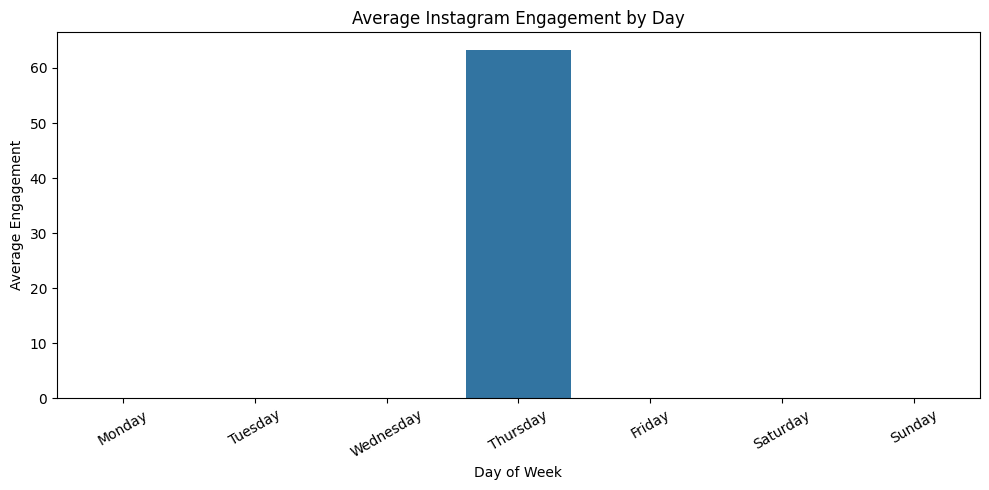

In [16]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=day_analysis,
    x="day_name",
    y="avg_engagement"
)

plt.title("Average Instagram Engagement by Day")
plt.xlabel("Day of Week")
plt.ylabel("Average Engagement")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [17]:
hour_analysis = (
    posts.groupby("hour")
    .agg(
        total_posts=("id", "count"),
        avg_likes=("likes", "mean"),
        avg_comments=("comments", "mean"),
        avg_engagement=("engagement", "mean"),
        avg_engagement_rate=("engagement_rate", "mean")
    )
    .reset_index()
)

display(hour_analysis.round(2))

,hour,total_posts,avg_likes,avg_comments,avg_engagement,avg_engagement_rate
0,8,257,34.17,29.14,63.31,44.44


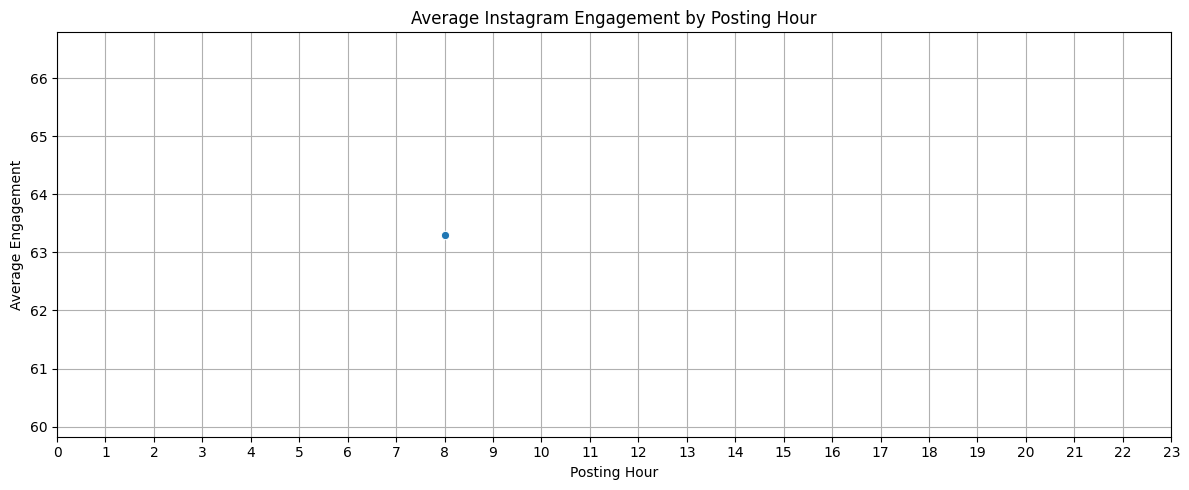

In [18]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hour_analysis,
    x="hour",
    y="avg_engagement",
    marker="o"
)

plt.title("Average Instagram Engagement by Posting Hour")
plt.xlabel("Posting Hour")
plt.ylabel("Average Engagement")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
content_analysis = (
    posts.groupby("photo type")
    .agg(
        total_posts=("id", "count"),
        avg_likes=("likes", "mean"),
        avg_comments=("comments", "mean"),
        avg_engagement=("engagement", "mean"),
        avg_engagement_rate=("engagement_rate", "mean")
    )
    .reset_index()
)

display(content_analysis.round(2))

,photo type,total_posts,avg_likes,avg_comments,avg_engagement,avg_engagement_rate
0,carousel,50,33.86,28.68,62.54,45.74
1,photo,155,34.39,29.25,63.63,43.65
2,video,52,33.83,29.25,63.08,45.57


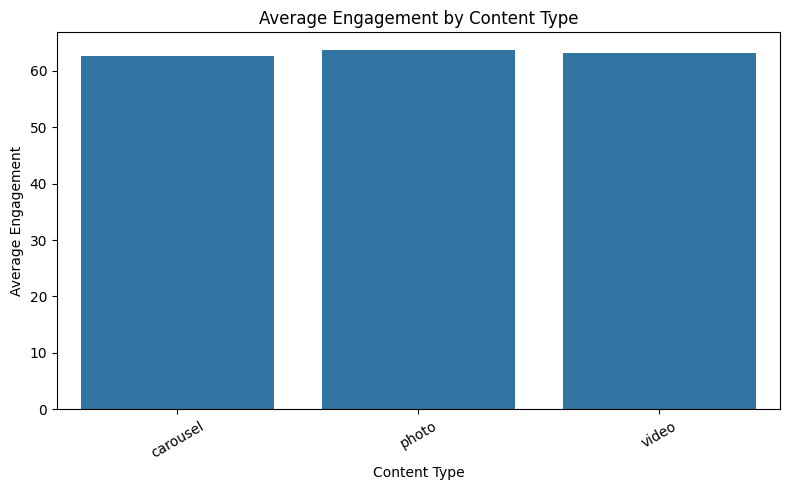

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=content_analysis,
    x="photo type",
    y="avg_engagement"
)

plt.title("Average Engagement by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Average Engagement")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [21]:
print(tags.columns.tolist())
print(photo_tags.columns.tolist())

display(tags.head())
display(photo_tags.head())

['id', 'tag text', 'created time', 'location']
['photo', 'tag ID', 'user id']


,id,tag text,created time,location
0,1,sunset,13-04-2023 08:04,florida
1,2,photography,13-04-2023 08:04,washington DC
2,3,sunrise,13-04-2023 08:04,new york
3,4,landscape,13-04-2023 08:04,london
4,5,food,13-04-2023 08:04,brazil


,photo,tag ID,user id
0,1,13,1
1,1,17,1
2,1,18,2
3,1,19,2
4,1,21,3


In [22]:
hashtag_data = photo_tags.merge(
    tags,
    left_on="tag ID",
    right_on="id",
    how="left"
)

hashtag_data = hashtag_data.merge(
    posts[["id", "likes", "comments", "engagement"]],
    left_on="photo",
    right_on="id",
    how="left"
)

hashtag_analysis = (
    hashtag_data.groupby("tag text")
    .agg(
        posts_used=("photo", "nunique"),
        avg_likes=("likes", "mean"),
        avg_comments=("comments", "mean"),
        avg_engagement=("engagement", "mean")
    )
    .reset_index()
)

hashtag_analysis = hashtag_analysis.sort_values(
    "avg_engagement",
    ascending=False
)

display(hashtag_analysis.head(15).round(2))

,tag text,posts_used,avg_likes,avg_comments,avg_engagement
3,delicious,15,34.93,30.33,65.27
1,beauty,20,34.95,30.20,65.15
8,foodie,11,34.73,29.91,64.64
20,sunset,19,34.21,30.21,64.42
17,stunning,16,34.94,29.31,64.25
7,food,24,33.83,30.29,64.12
15,photography,16,34.50,29.50,64.00
4,dreamy,20,35.75,28.15,63.90
16,smile,59,34.46,29.24,63.69
14,party,39,33.92,29.51,63.44


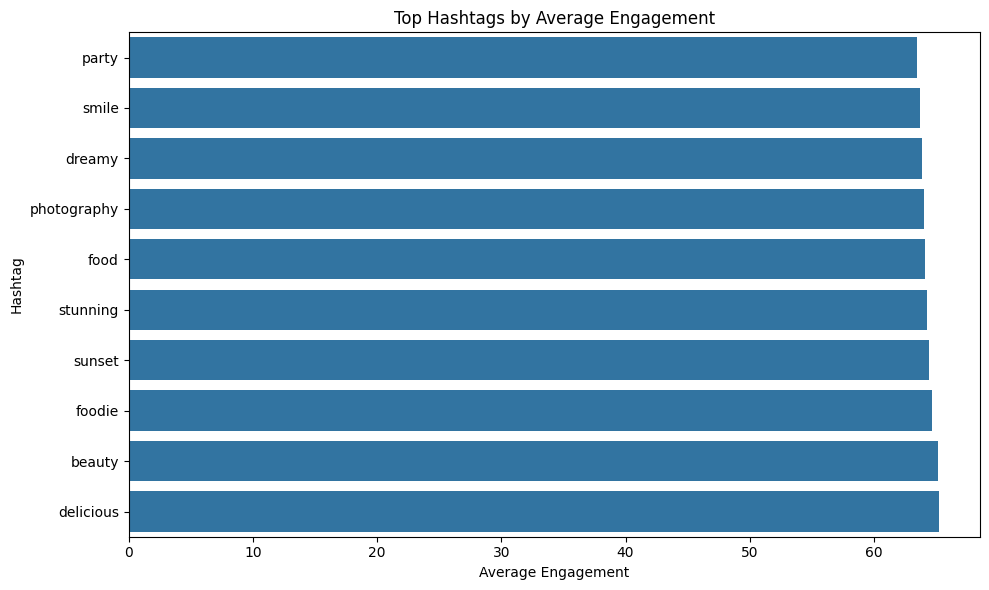

In [23]:
top_hashtags = hashtag_analysis.head(10).sort_values(
    "avg_engagement"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_hashtags,
    x="avg_engagement",
    y="tag text"
)

plt.title("Top Hashtags by Average Engagement")
plt.xlabel("Average Engagement")
plt.ylabel("Hashtag")
plt.tight_layout()
plt.show()

In [24]:
user_analysis = (
    posts.groupby("user ID")
    .agg(
        total_posts=("id", "count"),
        avg_likes=("likes", "mean"),
        avg_comments=("comments", "mean"),
        avg_engagement=("engagement", "mean"),
        avg_engagement_rate=("engagement_rate", "mean"),
        followers=("follower_count", "first")
    )
    .reset_index()
)

user_analysis = user_analysis.sort_values(
    "avg_engagement",
    ascending=False
)

display(user_analysis.head(15).round(2))

,user ID,total_posts,avg_likes,avg_comments,avg_engagement,avg_engagement_rate,followers
41,55,1,41.00,34.00,75.0,75.76,99.0
55,73,1,38.00,35.00,73.0,73.74,99.0
37,48,1,37.00,34.00,71.0,71.72,99.0
17,22,1,39.00,31.00,70.0,70.71,99.0
67,94,1,40.00,28.00,68.0,68.69,99.0
63,87,4,35.00,33.00,68.0,68.69,99.0
52,69,1,36.00,32.00,68.0,68.69,99.0
14,18,1,36.00,31.00,67.0,67.68,99.0
33,43,5,36.00,30.80,66.8,67.47,99.0
40,52,5,36.40,30.20,66.6,67.27,99.0


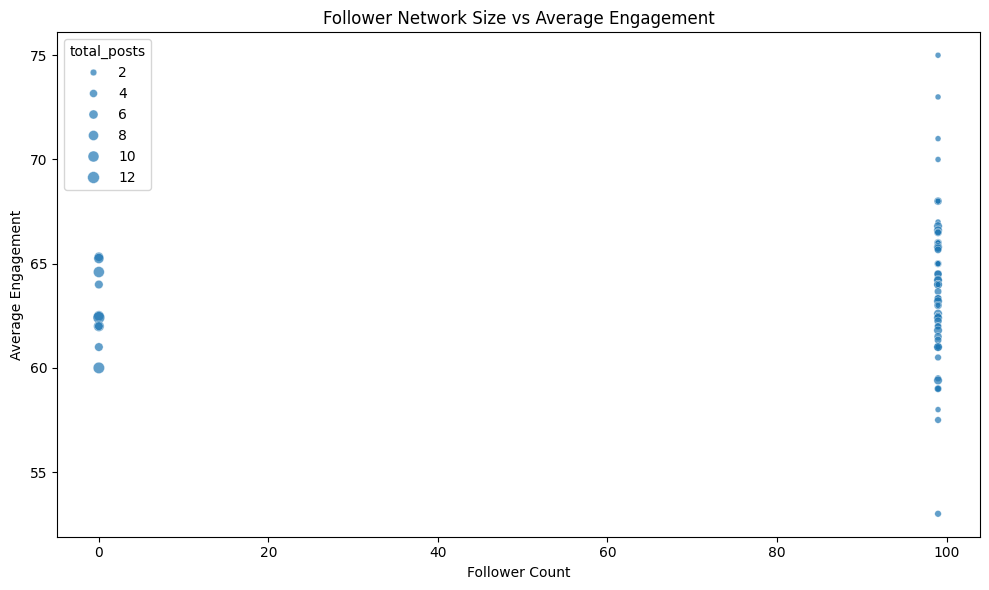

In [25]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=user_analysis,
    x="followers",
    y="avg_engagement",
    size="total_posts",
    alpha=0.7
)

plt.title("Follower Network Size vs Average Engagement")
plt.xlabel("Follower Count")
plt.ylabel("Average Engagement")
plt.tight_layout()
plt.show()

In [26]:
print("INSTAGRAM ENGAGEMENT ANALYSIS SUMMARY")
print("=" * 50)

print("\nOverall Performance")
print("-" * 50)
print("Total Posts:", len(posts))
print("Average Likes:", round(posts["likes"].mean(), 2))
print("Average Comments:", round(posts["comments"].mean(), 2))
print("Average Engagement:", round(posts["engagement"].mean(), 2))
print("Average Engagement Rate:", round(posts["engagement_rate"].mean(), 2), "%")

print("\nBest Posting Days")
print("-" * 50)
print(
    day_analysis
    .sort_values("avg_engagement", ascending=False)
    [["day_name", "avg_engagement", "avg_engagement_rate"]]
    .head(3)
    .round(2)
)

print("\nBest Posting Hours")
print("-" * 50)
print(
    hour_analysis
    .sort_values("avg_engagement", ascending=False)
    [["hour", "avg_engagement", "avg_engagement_rate"]]
    .head(5)
    .round(2)
)

print("\nContent Types")
print("-" * 50)
display(
    content_analysis
    .sort_values("avg_engagement", ascending=False)
    .round(2)
)

print("\nTop Hashtags")
print("-" * 50)
display(
    hashtag_analysis[
        ["tag text", "posts_used", "avg_engagement"]
    ].head(10).round(2)
)

INSTAGRAM ENGAGEMENT ANALYSIS SUMMARY

Overall Performance
--------------------------------------------------
Total Posts: 257
Average Likes: 34.17
Average Comments: 29.14
Average Engagement: 63.31
Average Engagement Rate: 44.44 %

Best Posting Days
--------------------------------------------------
   day_name  avg_engagement  avg_engagement_rate
0  Thursday           63.31                44.44

Best Posting Hours
--------------------------------------------------
   hour  avg_engagement  avg_engagement_rate
0     8           63.31                44.44

Content Types
--------------------------------------------------


,photo type,total_posts,avg_likes,avg_comments,avg_engagement,avg_engagement_rate
1,photo,155,34.39,29.25,63.63,43.65
2,video,52,33.83,29.25,63.08,45.57
0,carousel,50,33.86,28.68,62.54,45.74



Top Hashtags
--------------------------------------------------


,tag text,posts_used,avg_engagement
3,delicious,15,65.27
1,beauty,20,65.15
8,foodie,11,64.64
20,sunset,19,64.42
17,stunning,16,64.25
7,food,24,64.12
15,photography,16,64.00
4,dreamy,20,63.90
16,smile,59,63.69
14,party,39,63.44


# Instagram Engagement Strategy – Alfido Tech

## Executive Summary

This analysis examined 257 Instagram posts using likes, comments, follower-network data, content types, posting timestamps, and hashtags. The dataset recorded an average of **34.17 likes**, **29.14 comments**, and **63.31 total engagements per post**, with an average engagement rate of approximately **44.44%** based on the available follower-network data.

Content-type performance was relatively close across the available categories, with **photos averaging 63.63 engagements**, **videos 63.08**, and **carousels 62.54**. Hashtags such as **#delicious, #beauty, #foodie, #sunset, and #stunning** were associated with relatively high average engagement in this dataset.

The dataset records posts at the same timestamp — **Thursday at 08:04** — so it cannot establish a reliable best day or time for posting. Alfido Tech should therefore test multiple posting windows and measure actual account performance before establishing a permanent schedule.

## Recommended Content Calendar

| Day       | Suggested Content                     | Suggested Time |
| --------- | ------------------------------------- | -------------- |
| Monday    | Educational / AI or technology tip    | 9:00 AM        |
| Tuesday   | Project showcase / internship content | 1:00 PM        |
| Wednesday | Short educational Reel                | 7:00 PM        |
| Thursday  | Student success / testimonial         | 9:00 AM        |
| Friday    | Technology trend / career content     | 7:00 PM        |
| Saturday  | Behind-the-scenes / team content      | 11:00 AM       |
| Sunday    | Weekly recap / community post         | 6:00 PM        |

These are **testing windows**, not dataset-proven optimal times. Performance should be reviewed after several weeks and the schedule adjusted using Alfido Tech's actual Instagram analytics.

## Five Engagement Strategies

### 1. Increase educational short-form content

Create short Reels and carousels explaining AI, programming, internships, projects, and career skills. Use strong opening hooks and clear calls to action.

### 2. Showcase projects and outcomes

Regularly present student projects, internship work, certificates, demonstrations, and before-and-after results to make the content practical and credible.

### 3. Use relevant hashtag groups

Build several rotating hashtag groups around AI, technology, internships, programming, students, and career development. Track reach and engagement rather than relying only on hashtag popularity.

### 4. Encourage comments and conversations

Use questions, polls, quizzes, and discussion prompts such as “Which technology would you learn next?” or “Which AI project would you build?”

### 5. Test and optimize the posting schedule

Run controlled tests across morning, afternoon, and evening posting windows. Compare reach, likes, comments, saves, shares, profile visits, and follower changes, then adjust the calendar based on actual performance.

## Key Data Limitation

The supplied dataset contains 257 posts, but the recorded post timestamp is the same for the available records. Therefore, the analysis cannot reliably determine the best posting day or hour. The proposed schedule should be treated as an experimentation plan rather than a conclusion directly established by the dataset.

## Conclusion

The analysis indicates that engagement should be evaluated using multiple signals rather than likes alone. Alfido Tech can combine educational content, project showcases, interactive posts, relevant hashtags, and systematic posting-time experiments to build a measurable Instagram content strategy.
